This notebook analyzes the final analysis-ready datasets created during the data preparation and feature engineering pipeline.

Two analytical datasets are used:

- `df_master`: order-level dataset with a grain of 1 row = 1 order
- `funnel_master`: marketing and sales funnel dataset with a grain of *1 row = 1 marketing lead

The objective of this notebook is to explore business patterns, identify meaningful relationships, evaluate customer and operational behavior, and generate insights that can later be translated into business recommendations and Power BI dashboards.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_master = pd.read_csv("../data/final/df_master.csv")
funnel_master = pd.read_csv("../data/final/funnel_master.csv")

print("df_master shape:", df_master.shape)
print("funnel_master shape:", funnel_master.shape)

df_master shape: (99441, 69)
funnel_master shape: (8000, 32)


When re-reading columns from a CSV, date columns can end up as `object` type. That is why I convert them back to `datetime`.

In [3]:
df_master_datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "customer_first_order_date",
    "customer_last_order_date"
]

for col in df_master_datetime_cols:
    df_master[col] = pd.to_datetime(
        df_master[col],
        errors="coerce"
    )

In [4]:
funnel_datetime_cols = [
    "first_contact_date",
    "won_date"
]

for col in funnel_datetime_cols:
    funnel_master[col] = pd.to_datetime(
        funnel_master[col],
        errors="coerce"
    )

These metrics provide a high-level view of the business before moving into more detailed sales, customer, logistics, and funnel analyses.

In [5]:
analysis_start = df_master["order_purchase_timestamp"].min()
analysis_end = df_master["order_purchase_timestamp"].max()

total_orders = df_master["order_id"].nunique()
total_customers = df_master["customer_unique_id"].nunique()

total_sales = df_master["order_total_price"].sum()
average_order_value = df_master["order_total_price"].mean()

average_review_score = df_master["review_score"].mean()

late_delivery_rate = df_master["is_late_delivery"].mean()

total_leads = funnel_master["mql_id"].nunique()
won_leads = funnel_master["is_won"].sum()
conversion_rate = funnel_master["is_won"].mean()

average_days_to_close = funnel_master["days_to_close"].mean()
median_days_to_close = funnel_master["days_to_close"].median()

print("=== E-COMMERCE KPIs ===")
print("Analysis period:", analysis_start, "to", analysis_end)
print("Total orders:", total_orders)
print("Unique customers:", total_customers)
print("Total sales:", round(total_sales, 2))
print("Average order value:", round(average_order_value, 2))
print("Average review score:", round(average_review_score, 2))
print("Late delivery rate:", round(late_delivery_rate * 100, 2), "%")

print("\n=== MARKETING FUNNEL KPIs ===")
print("Total leads:", total_leads)
print("Won leads:", won_leads)
print("Conversion rate:", round(conversion_rate * 100, 2), "%")
print("Average days to close:", round(average_days_to_close, 2))
print("Median days to close:", round(median_days_to_close, 2))

=== E-COMMERCE KPIs ===
Analysis period: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Total orders: 99441
Unique customers: 96096
Total sales: 13591643.7
Average order value: 137.75
Average review score: 4.09
Late delivery rate: 7.87 %

=== MARKETING FUNNEL KPIs ===
Total leads: 8000
Won leads: 842
Conversion rate: 10.52 %
Average days to close: 48.5
Median days to close: 14.0


In this section, I examine how order activity and sales value change over time. This allows me to observe growth trends, seasonality, and periods of extreme business activity.

In [6]:
monthly_sales = (
    df_master
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

monthly_sales.head()

,order_purchase_timestamp,order_count,total_sales,average_order_value
0,2016-09-01,4,267.36,89.120000
1,2016-10-01,324,49507.66,160.739156
2,2016-11-01,0,0.00,NaN
3,2016-12-01,1,10.90,10.900000
4,2017-01-01,800,120312.87,152.487795


Monthly order volume and sales value show a clear growth trend throughout the period under review.

Order activity increased significantly during 2017, followed by a higher and relatively stable level of monthly activity in the first eight months of 2018.

I also examined the sharp decline observed in September and October 2018. There are very few order records for these months; the majority were cancelled, and no price information for individual order items is included.

Therefore, I interpreted this as a limitation regarding data coverage rather than an actual decline in business performance.

Consequently, for the monthly trend analysis, I treated August 2018 as the last month with sufficiently complete data. While retaining the original records in `df_master`, I excluded the subsequent months containing incomplete data from the analysis.

In [7]:
monthly_coverage = (
    df_master
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        order_count=("order_id", "nunique"),
        orders_with_price=("order_total_price", "count"),
        total_sales=("order_total_price", "sum")
    )
    .reset_index()
)

monthly_coverage.tail(6)

,order_purchase_timestamp,order_count,orders_with_price,total_sales
20,2018-05-01,6873,6853,996517.68
21,2018-06-01,6167,6160,865124.31
22,2018-07-01,6292,6273,895507.22
23,2018-08-01,6512,6452,854686.33
24,2018-09-01,16,1,145.00
25,2018-10-01,4,0,0.00


In [8]:
df_master[
    df_master["order_purchase_timestamp"] >= "2018-08-01"
][
    [
        "order_purchase_timestamp",
        "order_status",
        "order_total_price"
    ]
].sort_values("order_purchase_timestamp").tail(30)

,order_purchase_timestamp,order_status,order_total_price
30077,2018-08-29 14:18:23,delivered,418.00
31486,2018-08-29 14:18:28,delivered,45.90
69678,2018-08-29 14:52:00,delivered,24.90
88097,2018-08-29 15:00:37,delivered,84.99
2029,2018-08-29 16:27:49,canceled,NaN
17983,2018-08-30 10:14:00,canceled,NaN
25953,2018-08-30 10:24:34,canceled,NaN
29915,2018-08-30 13:07:46,canceled,NaN
88141,2018-08-30 15:11:58,canceled,NaN
99283,2018-08-31 16:13:44,canceled,NaN


That is why I created a view named "monthly_sales_complete." This way, no data is lost and the source remains untouched; instead, we simply define the scope of analysis for a specific business question.

In [9]:
monthly_sales_complete = monthly_sales[
    monthly_sales["order_purchase_timestamp"] <= "2018-08-01"
].copy()

monthly_sales_complete.tail()

,order_purchase_timestamp,order_count,total_sales,average_order_value
19,2018-04-01,6939,996647.75,143.733451
20,2018-05-01,6873,996517.68,145.413349
21,2018-06-01,6167,865124.31,140.442258
22,2018-07-01,6292,895507.22,142.755814
23,2018-08-01,6512,854686.33,132.468433


Based on the dataframe I just created, I generated line charts showing the number of orders and total sales amounts by month.

Throughout 2017, both order volume and sales value show significant growth. From late 2017 onwards, monthly performance rises to a much higher level. In the first eight months of 2018, the number of orders hovers roughly in the 6,000–7,000 range, while monthly sales remain around 0.85–1.0 million.

In short, the overall picture shows strong growth from the early period leading into 2018, followed by relative stabilization at a high level.

The distinct peak around November 2017 is also noteworthy; I might examine that further later on.

In [10]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 1 Axes>

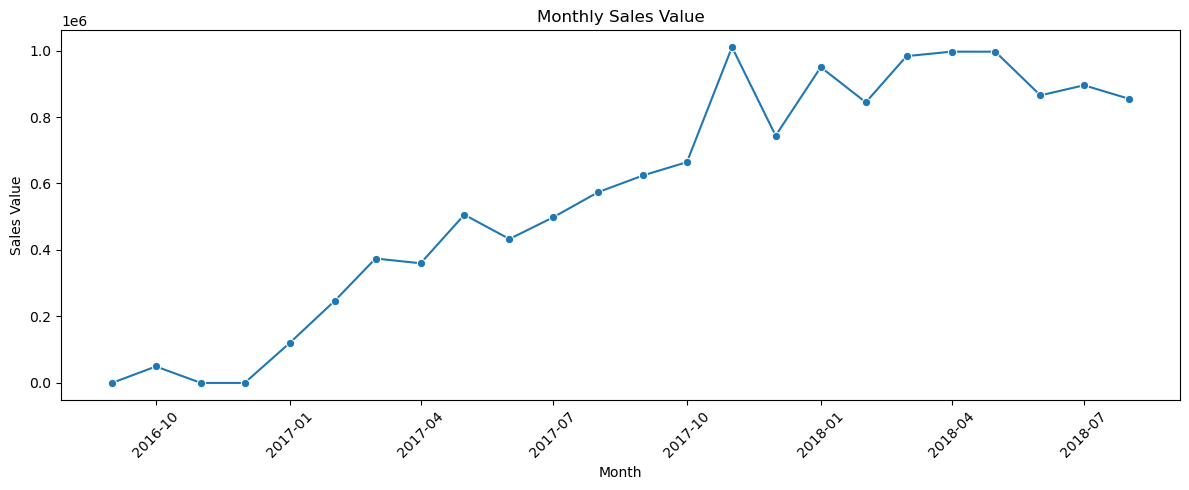

In [11]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="total_sales",
    marker="o"
)

plt.title("Monthly Sales Value")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To understand whether sales growth is driven by higher spending per order or primarily by increasing order volume, I analyzed the monthly Average Order Value (AOV).

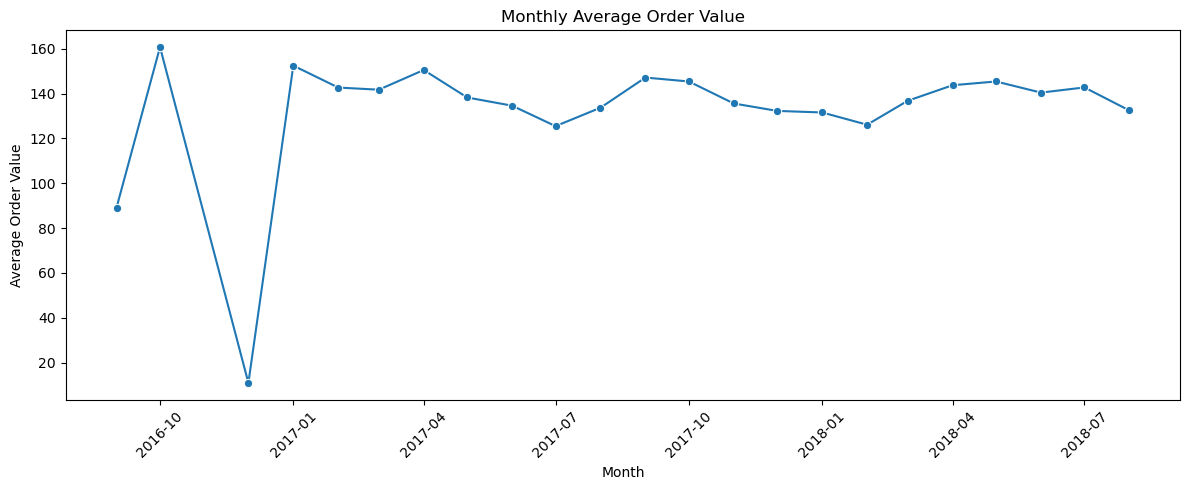

In [12]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales_complete,
    x="order_purchase_timestamp",
    y="average_order_value",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Average Monthly Order Value has remained relatively stable throughout the dataset's primary period of activity.

Although significant fluctuations were observed in the initial months, these movements stemmed from very low order volumes.

From 2017 onwards, while monthly order volume and total sales increased substantially, the Average Order Value (AOV) generally remained within a relatively narrow range.

This indicates that the overall sales growth observed in the dataset was driven primarily by an increase in transaction volume rather than by a sustained rise in spending per order.

In [13]:
monthly_sales_complete[
    [
        "order_purchase_timestamp",
        "order_count",
        "total_sales",
        "average_order_value"
    ]
].tail(12)

,order_purchase_timestamp,order_count,total_sales,average_order_value
12,2017-09-01,4285,624401.69,147.160427
13,2017-10-01,4631,664219.43,145.407056
14,2017-11-01,7544,1010271.37,135.588695
15,2017-12-01,5673,743914.17,132.274924
16,2018-01-01,7269,950030.36,131.583152
17,2018-02-01,6728,844178.71,126.109756
18,2018-03-01,7211,983213.44,136.785398
19,2018-04-01,6939,996647.75,143.733451
20,2018-05-01,6873,996517.68,145.413349
21,2018-06-01,6167,865124.31,140.442258


I analyzed order activity on a day-by-day basis.

Order volumes are higher on weekdays compared to weekends; the highest number of orders is recorded on Mondays, while the lowest is recorded on Saturdays. Order activity generally tends to decline from the beginning to the end of the work week, followed by a marked drop over the weekend.

However, the Average Order Value remains relatively consistent across weekdays. This indicates that variations in total daily sales stem primarily from the number of transactions rather than from significant fluctuations in spending per order.

In [15]:
weekday_orders = (
    df_master
    .groupby("purchase_weekday")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

weekday_orders

,purchase_weekday,order_count,total_sales,average_order_value
0,Friday,14122,1962426.75,140.153317
1,Monday,16196,2230812.51,138.835730
2,Saturday,10887,1504018.36,139.093532
3,Sunday,11960,1589278.89,133.687659
4,Thursday,14761,2018615.78,137.893010
5,Tuesday,15963,2172647.82,137.240087
6,Wednesday,15552,2113843.59,137.040103


In [16]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_orders["purchase_weekday"] = pd.Categorical(
    weekday_orders["purchase_weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_orders = weekday_orders.sort_values(
    "purchase_weekday"
)

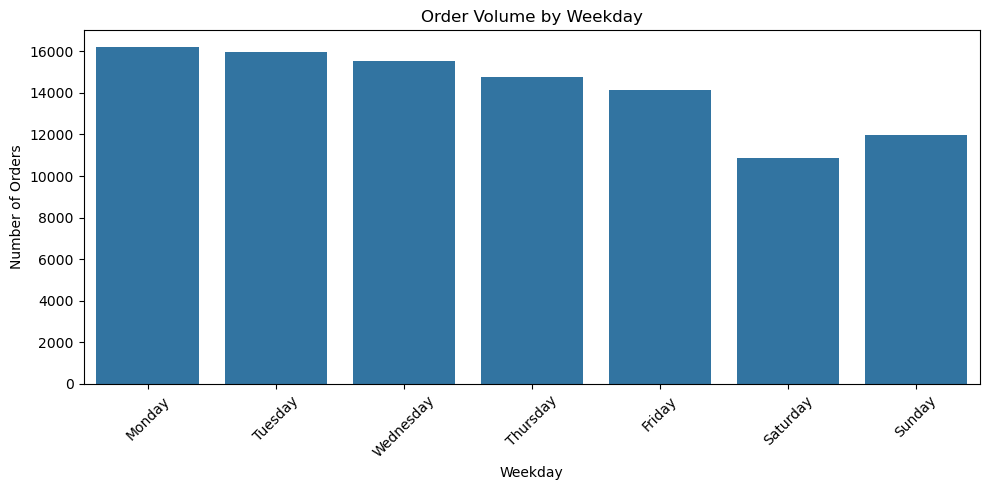

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_orders,
    x="purchase_weekday",
    y="order_count"
)

plt.title("Order Volume by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To understand when customers are most active, I categorized orders into four distinct purchasing periods. For each period, I calculated the order volume, total sales amount, and Average Order Value.

This analysis helps identify the timeframes with the highest purchasing activity and determine whether variations in sales stem primarily from transaction volume or from changes in the amount spent per order.

While order volume peaks in the afternoon, purchasing activity is significantly lower during the evening hours.

Average Order Value also varies across these periods, reaching its highest level in the afternoon and its lowest at night. However, the variations in average order value are relatively modest compared to the differences in transaction volume.

This indicates that the higher sales figures recorded in the afternoon and evening are primarily driven by increased purchasing activity rather than by significant fluctuations in spending per order.

In [18]:
purchase_period_summary = (
    df_master
    .groupby("purchase_period")
    .agg(
        order_count=("order_id", "nunique"),
        total_sales=("order_total_price", "sum"),
        average_order_value=("order_total_price", "mean")
    )
    .reset_index()
)

purchase_period_summary

,purchase_period,order_count,total_sales,average_order_value
0,Afternoon,38361,5344650.00,140.430647
1,Evening,34100,4650802.19,137.337650
2,Morning,22240,2992326.39,135.749507
3,Night,4740,603865.12,128.481940


In [19]:
period_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

purchase_period_summary["purchase_period"] = pd.Categorical(
    purchase_period_summary["purchase_period"],
    categories=period_order,
    ordered=True
)

purchase_period_summary = purchase_period_summary.sort_values(
    "purchase_period"
)

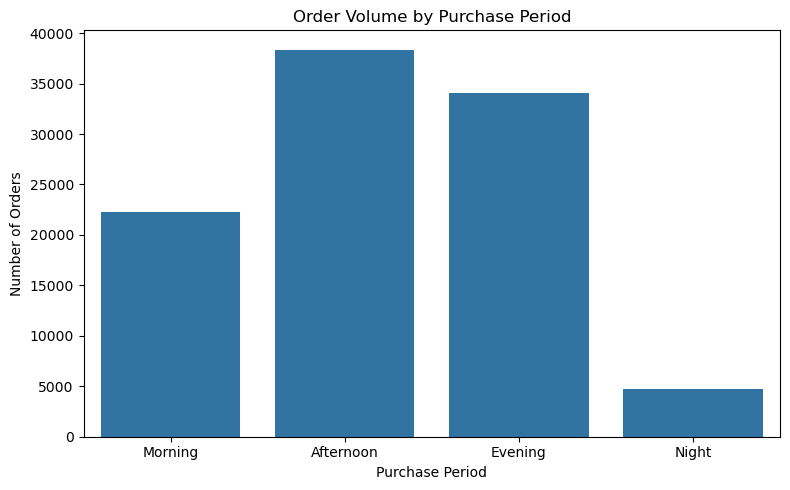

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=purchase_period_summary,
    x="purchase_period",
    y="order_count"
)

plt.title("Order Volume by Purchase Period")
plt.xlabel("Purchase Period")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()